---
title: Sentinel‑2 L1C UTM to HEALPix
subtitle: This notebook demonstrates a clear, reproducible workflow to convert Sentinel‑2 L1C data from its native UTM projection to a global **HEALPix** grid

authors:
  - name: Suriyah Dhinakaran
    orcid: 0009-0007-0355-7372
    github: suriyahgit
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Benoit Bovy
    orcid: 0009-0001-4011-3574
    github: benbovy
    affiliations:
      - id: Georode
        institution: Georode
        ror: 01xt1w755
  - name:   
date: 2025-12-02
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing"]
tags: ["template"]
releaseDate: 2025-12-02
datePublished: 2025-12-02
dateModified: 2025-12-02
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

## Table of Contents

1. [Introduction](#introduction)
2. [Setup](#setup)
3. [Data Access via STAC](#data-access-via-stac)
4. [Open the Sentinel‑2 Product](#open-the-sentinel2-product)
5. [Subset a Region of Interest](#subset-a-region-of-interest)
6. [Quicklook & Visualization](#quicklook--visualization)
7. [Add Latitude/Longitude Coordinates](#add-latitudelongitude-coordinates)
8. [Transforming Gridded Data to a HEALPix Representation](#transforming-gridded-data-to-a-healpix-representation)
9. [Convert to HEALPix](#convert-to-healpix)
10. [Inspect the HEALPix Output](#inspect-the-healpix-output)
11. [Appendix / References](#appendix--references)

(Introduction)=
## Introduction

Sentinel-2 Level-1C products are distributed as **UTM-projected tiles**, optimised for local cartographic accuracy but not for global, multi-tile, or multi-sensor analysis. UTM zones vary in scale distortion with latitude, and stitching tiles across boundaries introduces heterogeneity that is problematic for large-scale modelling, harmonisation, and comparative EO studies.

For global or continental analyses, it is advantageous to work in a **sphere-aware, equal-area reference system** where every cell represents an equivalent portion of the Earth’s surface. **HEALPix**—the Hierarchical Equal Area isoLatitude Pixelisation—is one such system. Its equal-area property eliminates latitudinal bias, and its hierarchical refinement supports scalable computations across resolutions.

This notebook presents a clear, modular workflow for converting **EOPF-compliant UTM-based Zarr datasets** (e.g., Sentinel-2 L1C and L2A) into a **HEALPix-indexed data cube**. Because EOPF datasets follow a Datatree architecture, the procedure generalises to any UTM-expressed product stored in EOPF Zarr format. The notebook focuses on converting **specific Regions of Interest (ROIs)** from the original tile into HEALPix space, avoiding the computational cost of full-tile reprojection. The workflow is a transparent sequence of steps: loading, coordinate interpretation, reprojection of the ROI to geographic space, HEALPix indexing, and reconstruction of a HEALPix-backed data cube.


### 🧭 Why DGGS?

A **Discrete Global Grid System (DGGS)** provides a spatial reference system that partitions the Earth using hierarchical, equal-area cells (OGC Topic 21, 2017). DGGS frameworks address core limitations of traditional map projections, where scale distortion varies substantially across latitude and map extent.

<p align="center">
  <img src="https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/latlon_dggs.png" width="480">
</p>

DGGS architectures offer:

* **Equal-area representation** (minimising latitudinal bias in statistics)
* **Seamless global coverage** (no projection zones, no discontinuities)
* **Hierarchical refinement** (consistent multi-resolution analysis)

Among the various DGGS families, **HEALPix** is widely used in planetary sciences, cosmology, and increasingly in climate and EO applications due to its strict equal-area property and efficient spherical indexing.

### 🧩 DGGS Examples

<table style="width:100%; table-layout:fixed;">
<tr>
<td style="text-align:center;">

#### H3

Hexagonal, hierarchical
Common in geospatial analytics and mobility studies

<img src="https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/H3.png" width="180">

</td>
<td style="text-align:center;">

#### HEALPix

Equal-area, iso-latitude, hierarchical
Suitable for global EO, climate, and model fusion

<img src="https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/healpix0.png" width="180">

</td>
</tr>
</table>

</td>
  </tr>
  <tr>
    <td colspan="2" style="padding-top:10px; font-size:90%;">

Both figures are from:  
Kmoch et al. (2024). *XDGGS: A community-developed Xarray package to support planetary DGGS data cube computations.* [doi:10.5194/isprs-archives-XLVIII-4-W12-2024-75-2024](https://doi.org/10.5194/isprs-archives-XLVIII-4-W12-2024-75-2024)

  </tr>
</table>

HEALPix maintains excellent equal-area behaviour across all latitudes:-

### Area Distortion Analysis

The figure below (also from Kmoch et al., 2024) summarizes normalized area values for various DGGS types, highlighting HEALPix's strong equal-area properties.


<p align="center">
  <img src="https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/fig2.png" width="360">
</p>


---

:::{hint} Overview  

**Questions**

* How can specific ROIs within UTM-projected Sentinel-2 L1C/L2A data stored in EOPF Zarr format be transformed into a HEALPix-based DGGS representation?
* What steps are required to extract georeferencing for an ROI, reproject pixel coordinates, and map them onto the HEALPix grid?
* Why is HEALPix advantageous for global or multi-sensor Earth observation workflows compared to UTM or lat-lon grids?
* How does the Datatree structure of EOPF datasets support scalable, DGGS-ready data transformation for targeted regions?

**Objectives**

* Learn how to read and interpret Sentinel-2 EOPF Zarr datasets in UTM projection using their Datatree metadata structure.
* Understand the workflow for converting UTM pixel coordinates for an ROI to geodetic (lat/lon) space and assigning them to HEALPix cells.
* Build a HEALPix-indexed data cube from UTM-based Sentinel-2 ROI inputs following a reproducible, modular pipeline.
* Produce HEALPix-aligned outputs suitable for global modelling, aggregation, statistical analysis, and multi-resolution EO applications.

:::

## Setup

In [1]:
!pip install healpix-geo

In [2]:
import numpy as np
import pyproj
import pystac_client
import xarray as xr
import pathlib
from healpix_geo.nested import lonlat_to_healpix
from dask_gateway import Gateway

In [3]:
# Simplest way - creates everything automatically in the eopf jupyterhub dask cluster
gate = Gateway()
cluster = gate.new_cluster()

## Data Access via STAC and Xarray

We query the EOPF STAC catalog for suitable satellite data (e.g., Sentinel‑2 L1C or L2A with low cloud cover, good sun elevation) and obtain Zarr assets. These datasets are opened with Xarray using lazy loading with Dask when chunked. The workflow is collection‑agnostic—simply specify `"sentinel-2-l1c"` or `"sentinel-2-l2a"` as needed.

In [4]:
# Access cloud-optimized Sentinel-2 data via the EOPF STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Define oceanographic study area and time window
LON, LAT = -4.5, 48  # Bay of Biscay - known for consistent wave patterns
date = "2025-06-17/2025-06-17"

# Search criteria optimized for wave analysis

collection = "sentinel-2-l1c"
items = list(
    catalog.search(
        datetime=date,
        collections=[collection],
        intersects=dict(type="Point", coordinates=[LON, LAT]),
        query={
            "eo:cloud_cover": {
                "lt": 20
            },  # Cloud cover < 20% ensures clear ocean surface
            "view:sun_elevation": {
                "gt": 25
            },  # Filter for high sun elevation > 25° (→ sun zenith angle < 65°),
            # which places the sun near the zenith.
        },
    ).items()
)

for item in items:
    print(f"✅ {item.id}")

item = items[0]

# Open the dataset lazily from object storage
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)

dt

✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UUU_20250617T131418


<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 7)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * detector                       (detector) int64 56B 3 4 5 6 7 8 9
│   │         * x                              (x) int64 184B 300000 305000 ... 410000
│   │         * y                              (y) int64 184B 5400000 5395000 ... 5290000
│   │       Data variables:
│   │           mean_sun_angles                (angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
│   │           mean_viewing_incidence_angles  (band, angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
│   │           sun_angles                     (angle, y, x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
│   │           viewing_incidence_angles       (band, detector, angle, y, x) float64 770kB dask.array<chunksize=(7, 4, 2, 23, 23), meta=np.ndarray>
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   ├── Group: /conditions/mask/detector_footprint/r10m
│   │   │   │       Dimensions:  (y: 10980, x: 10980)
│   │   │   │       Coordinates:
│   │   │   │         * x        (x) int64 88kB 300005 300015 300025 300035 ... 409775 409785 409795
│   │   │   │         * y        (y) int64 88kB 5399995 5399985 5399975 ... 5290225 5290215 5290205
│   │   │   │       Data variables:
│   │   │   │           b02      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b03      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b04      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b08      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   ├── Group: /conditions/mask/detector_footprint/r20m
│   │   │   │       Dimensions:  (y: 5490, x: 5490)
│   │   │   │       Coordinates:
│   │   │   │         * x        (x) int64 44kB 300010 300030 300050 300070 ... 409750 409770 409790
│   │   │   │         * y        (y) int64 44kB 5399990 5399970 5399950 ... 5290250 5290230 5290210
│   │   │   │       Data variables:
│   │   │   │           b05      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b06      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b07      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b11      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b12      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b8a      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   └── Group: /conditions/mask/detector_footprint/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │   │           Coordinates:
│   │   │             * x        (x) int64 15kB 300030 300090 300150 300210 ... 409650 409710 409770
│   │   │             * y        (y) int64 15kB 5399970 5399910 5399850 ... 5290350 5290290 5290230
│   │   │           Data variables:
│   │   │               b01      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b09      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b10      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   └── Group: /conditions/mask/l1c_classification
│   │       └── Group: /conditions/mask/l1c_classification/r60m
│   │               Dimensions:  (y: 1830, x: 18

In [5]:
# Access cloud-optimized Sentinel-2 data via the EOPF STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Define oceanographic study area and time window
LON, LAT = -4.5, 48  # Bay of Biscay - known for consistent wave patterns
date = "2025-06-17/2025-06-17"

# Search criteria optimized for wave analysis

collection = "sentinel-2-l1c"
items = list(
    catalog.search(
        datetime=date,
        collections=[collection],
        intersects=dict(type="Point", coordinates=[LON, LAT]),
        query={
            "eo:cloud_cover": {
                "lt": 20
            },  # Cloud cover < 20% ensures clear ocean surface
            "view:sun_elevation": {
                "gt": 25
            },  # Filter for high sun elevation > 25° (→ sun zenith angle < 65°),
            # which places the sun near the zenith.
        },
    ).items()
)

for item in items:
    print(f"✅ {item.id}")

item = items[0]

# Open the dataset lazily from object storage
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)

dt

✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UUU_20250617T131418


<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 7)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * detector                       (detector) int64 56B 3 4 5 6 7 8 9
│   │         * x                              (x) int64 184B 300000 305000 ... 410000
│   │         * y                              (y) int64 184B 5400000 5395000 ... 5290000
│   │       Data variables:
│   │           mean_sun_angles                (angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
│   │           mean_viewing_incidence_angles  (band, angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
│   │           sun_angles                     (angle, y, x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
│   │           viewing_incidence_angles       (band, detector, angle, y, x) float64 770kB dask.array<chunksize=(7, 4, 2, 23, 23), meta=np.ndarray>
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   ├── Group: /conditions/mask/detector_footprint/r10m
│   │   │   │       Dimensions:  (y: 10980, x: 10980)
│   │   │   │       Coordinates:
│   │   │   │         * x        (x) int64 88kB 300005 300015 300025 300035 ... 409775 409785 409795
│   │   │   │         * y        (y) int64 88kB 5399995 5399985 5399975 ... 5290225 5290215 5290205
│   │   │   │       Data variables:
│   │   │   │           b02      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b03      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b04      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b08      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   ├── Group: /conditions/mask/detector_footprint/r20m
│   │   │   │       Dimensions:  (y: 5490, x: 5490)
│   │   │   │       Coordinates:
│   │   │   │         * x        (x) int64 44kB 300010 300030 300050 300070 ... 409750 409770 409790
│   │   │   │         * y        (y) int64 44kB 5399990 5399970 5399950 ... 5290250 5290230 5290210
│   │   │   │       Data variables:
│   │   │   │           b05      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b06      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b07      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b11      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b12      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b8a      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   └── Group: /conditions/mask/detector_footprint/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │   │           Coordinates:
│   │   │             * x        (x) int64 15kB 300030 300090 300150 300210 ... 409650 409710 409770
│   │   │             * y        (y) int64 15kB 5399970 5399910 5399850 ... 5290350 5290290 5290230
│   │   │           Data variables:
│   │   │               b01      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b09      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b10      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   └── Group: /conditions/mask/l1c_classification
│   │       └── Group: /conditions/mask/l1c_classification/r60m
│   │               Dimensions:  (y: 1830, x: 18

## Open the Sentinel‑2 Product

We open the product directly as an **Xarray DataTree** (lazy) to navigate measurements, conditions, and multi‑resolution groups (10m/20m/60m).

## Subset a Region of Interest

We extract a small ROI to demonstrate transformation and HEALPix conversion on a compact example.

In [6]:
dt["conditions"]["geometry"]["sun_angles"]

<xarray.DataArray 'sun_angles' (angle: 2, y: 23, x: 23)> Size: 8kB
dask.array<open_dataset-sun_angles, shape=(2, 23, 23), dtype=float64, chunksize=(2, 23, 23), chunktype=numpy.ndarray>
Coordinates:
  * angle    (angle) <U7 56B 'zenith' 'azimuth'
  * x        (x) int64 184B 300000 305000 310000 315000 ... 400000 405000 410000
  * y        (y) int64 184B 5400000 5395000 5390000 ... 5300000 5295000 5290000
Attributes: (1)

In [7]:
small_dt = dt.sel(
    x=slice(
        dt["conditions"]["geometry"]["sun_angles"].x[0],
        dt["conditions"]["geometry"]["sun_angles"].x[1],
    ),
    y=slice(
        dt["conditions"]["geometry"]["sun_angles"].y[-2],
        dt["conditions"]["geometry"]["sun_angles"].y[-1],
    ),
)

## Quicklook & Visualization

We visualize one or more bands (e.g., B02) to confirm the ROI and interpret pixel values before reprojection.

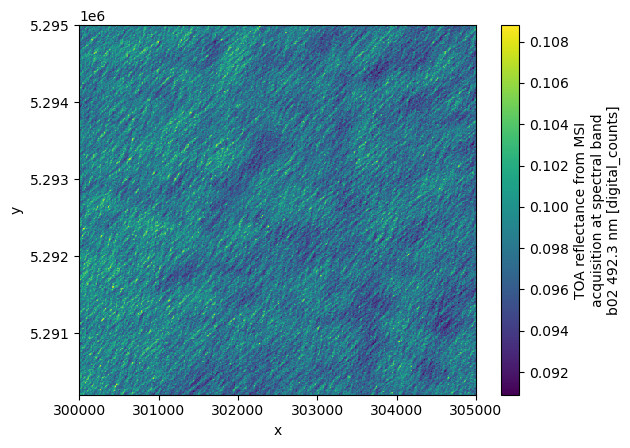

In [8]:
small_dt["measurements"]["reflectance"]["r10m"]["b02"].plot()

## Add Latitude/Longitude Coordinates

Using **pyproj** we transform UTM (x/y in meters) to geographic coordinates (lon/lat in degrees) and attach them as auxiliary coordinates. This enables subsequent binning onto a spherical grid.

In [9]:
def _add_latlon(ds: xr.Dataset, transformer: pyproj.Transformer) -> xr.Dataset:
    """Attach latitude/longitude coords + CF metadata to a Dataset with (x,y)."""
    if not {"x", "y"}.issubset(ds.dims):
        return ds

    xx, yy = np.meshgrid(ds["x"].values, ds["y"].values, indexing="xy")
    lon, lat = transformer.transform(xx, yy)

    ds = ds.assign_coords(
        longitude=(("y", "x"), lon),
        latitude=(("y", "x"), lat),
    )
    ds["latitude"].attrs.update(
        {
            "standard_name": "latitude",
            "long_name": "Latitude",
            "units": "degrees_north",
            "axis": "Y",
        }
    )
    ds["longitude"].attrs.update(
        {
            "standard_name": "longitude",
            "long_name": "Longitude",
            "units": "degrees_east",
            "axis": "X",
        }
    )

    # Make sure vars with (y,x) advertise the aux coords
    for var in ds.data_vars:
        if {"y", "x"}.issubset(ds[var].dims):
            existing = ds[var].attrs.get("coordinates", "").split()
            ds[var].attrs["coordinates"] = " ".join(
                sorted(set(existing) | {"latitude", "longitude"})
            )
    return ds


def add_latlon(
    path: str, ds: xr.Dataset, transformer: pyproj.Transformer
) -> xr.Dataset:
    """Wrapper for safe application on a node dataset."""
    if ds is None:
        print(path, "no dataset")
        return ds
    if not {"x", "y"}.issubset(ds.dims):
        print(path, "not both x,y")
        return ds
    return _add_latlon(ds, transformer)


def add_latlon_to_dt(dt: xr.DataTree) -> xr.DataTree:
    """Return a new DataTree with latitude/longitude coords added everywhere possible."""
    crs_code = dt.attrs["other_metadata"]["horizontal_CRS_code"]
    src_crs = pyproj.CRS.from_string(crs_code)
    transformer = pyproj.Transformer.from_crs(
        src_crs, pyproj.CRS.from_epsg(4326), always_xy=True
    )
    return xr.DataTree.from_dict(
        {
            path: add_latlon(path, node.ds, transformer)
            for path, node in dt.subtree_with_keys
        }
    )

In [10]:
%%time
latlon_dt = add_latlon_to_dt(small_dt)

. not both x,y
conditions not both x,y
measurements not both x,y
quality not both x,y
conditions/mask not both x,y
conditions/meteorology not both x,y
measurements/reflectance not both x,y
quality/l1c_quicklook not both x,y
quality/mask not both x,y
conditions/mask/detector_footprint not both x,y
conditions/mask/l1c_classification not both x,y
conditions/meteorology/cams not both x,y
conditions/meteorology/ecmwf not both x,y
CPU times: user 286 ms, sys: 370 μs, total: 286 ms
Wall time: 286 ms


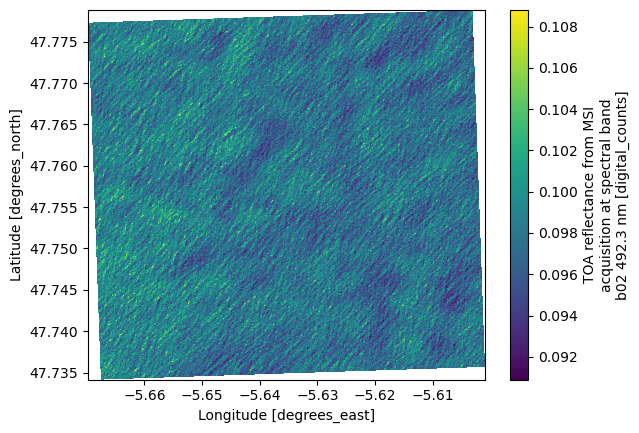

In [11]:
latlon_dt["measurements"]["reflectance"]["r10m"]["b02"].plot(
    x="longitude", y="latitude"
)

## Transforming Gridded Data to a HEALPix Representation

The following functions implement a complete pipeline to **convert geolocated raster data on a Cartesian grid** (with dimensions `x` and `y`) into a **HEALPix-based spherical grid**, which is ideal for global and multi-resolution analysis.

This is a fundamental part of bridging classical satellite data with hierarchical spherical representations used in cosmology and global geoscience.

---

## 📏 1. Choosing the Appropriate HEALPix Resolution

The first step is to decide the HEALPix `level` (or `nside`), which defines the resolution of the spherical grid. The edge length of a HEALPix cell is:

$$
\text{edge}(L) = R \frac{\sqrt{\pi/3}}{2^L}
$$

- $R$ is Earth's radius (≈ 6,371,000 m as defined in `EARTH_RADIUS_M`).
- $L$ is the HEALPix level (integer, 0-29).

The function `_choose_healpix_level_from_dx()` estimates the level so that the **HEALPix cell edge length is not smaller than the input grid spacing** $\Delta x$:

$$
L = \left\lfloor \log_2\left( \frac{R \sqrt{\pi/3}}{\Delta x} \right) \right\rfloor
$$

### Key Functions:
- `_infer_dx_from_x()`: Estimates grid spacing from x-coordinate values
- `_choose_healpix_level_from_dx()`: Computes appropriate HEALPix level
- `_healpix_edge_length_m()`: Calculates physical edge length for a given level

---

## 🗺️ 2. Converting Coordinates to HEALPix Cell IDs

We convert each pixel's latitude and longitude to HEALPix cell IDs using the `healpix-geo` library's `lonlat_to_healpix()` function:

```python
cell_ids = lonlat_to_healpix(lon, lat, level, ellipsoid="WGS84")
```

This gives a unique integer for each cell on the sphere using the **NESTED** indexing scheme.

---

## 📊 3. Grouping and Aggregating Data

The core transformation is performed by `_to_healpix_cells_grouped_mean()`:

### 3.1 Process Flow:
1. **Flatten and hash**: Convert 2D (y, x) arrays to 1D and compute HEALPix cell IDs
2. **Stack coordinates**: Combine y and x dimensions into a single "cells" dimension
3. **Assign cell IDs**: Attach HEALPix cell IDs as a coordinate
4. **Group and average**: Group by cell ID and compute mean values:

$$
\bar{v}_i = \frac{1}{N_i} \sum_{j \in \text{cell } i} v_j
$$

where $N_i$ is the number of original pixels mapping to HEALPix cell $i$.

### 3.2 Data Structure Transformation:
- **Input**: Dataset with dimensions `(y, x)`
- **Output**: Dataset with dimension `(cells)` where each cell corresponds to a unique HEALPix ID
- **Preservation**: All non-spatial dimensions (e.g., `angle`, bands) are maintained

---

## 🛠️ 4. Updating Metadata and Grid Mapping

Once data is reprojected into HEALPix, `_update_group_metadata()` ensures CF-compliance:

### 4.1 Grid Mapping Variable:
Adds a `crs` variable with HEALPix-specific attributes:
- `grid_mapping_name: healpix`
- `indexing_scheme: nested`
- `refinement_ratio: 4`
- `refinement_level: L` (the computed level)
- `reference_body: WGS84` (or specified ellipsoid)

### 4.2 Variable Attributes:
- Updates `coordinates` attribute to point to `cell_ids`
- Adds `grid_mapping` attribute to reference the `crs` variable
- Removes projection-specific (`proj:`) attributes
- Preserves `_eopf_attrs` metadata when present

---

## 🌐 5. Processing DataTree Structures

The main entry point `add_healpix_to_dt()` applies the transformation **recursively** to all groups in a `DataTree`:

### 5.1 Group Processing Logic:
```python
for path, group in dt.subtree_with_keys:
    if has_latlon_and_xy:
        # Convert to HEALPix
        level = _choose_healpix_level_from_dx(group.ds)
        ds_healpix = _to_healpix_cells_grouped_mean(group.ds, level)
        ds_healpix = _update_group_metadata(ds_healpix, level)
    elif has_xy_but_no_latlon:
        # Critical error - abort entire operation
        raise RuntimeError("Missing latitude/longitude coordinates")
    else:
        # Skip - no transformation needed
        pass
```

### 5.2 Multi-scale Organization:
- Groups are renamed by their HEALPix level (e.g., `/0`, `/1`, `/2`)
- Parent directories receive `multiscales` attribute for hierarchical access
- STAC discovery metadata is updated to reflect HEALPix geometry

---

## ⚠️ 6. Error Handling and Validation

The implementation includes robust error checking:

1. **Required coordinates**: Must have both `latitude` and `longitude` in degrees
2. **Required dimensions**: Must have `y` and `x` dimensions
3. **Valid grid spacing**: Must infer a positive, finite Δx from x-coordinates
4. **Level bounds**: HEALPix level is clipped between 0 and 29
5. **Early abortion**: If any dataset has x/y dimensions but lacks lat/lon coordinates, the entire operation fails

---

## 📦 Summary of the Workflow

| Step | Function | Purpose |
|------|----------|---------|
| 1 | `_infer_dx_from_x` | Estimate grid spacing from x-coordinates |
| 2 | `_choose_healpix_level_from_dx` | Compute optimal HEALPix level |
| 3 | `_to_healpix_cells_grouped_mean` | Convert lat/lon → HEALPix IDs and group average |
| 4 | `_update_group_metadata` | Add CF-compliant grid mapping and attributes |
| 5 | `_add_healpix_to_group` | Process individual dataset with error handling |
| 6 | `add_healpix_to_dt` | Apply transformation across DataTree hierarchy |
| 7 | `_update_stac_discovery` | Update STAC metadata for HEALPix representation |

---

✅ **Result**: Your dataset is now in a **HEALPix spherical format** with proper CF metadata, ready for multi-resolution storage, visualization, and cross-domain analysis (astronomy, geoscience, climate, etc.). The transformation preserves data integrity while enabling spherical harmonic analysis and global consistency checks.

In [12]:
# --- level selection (coarsest grid not finer than dx) ---
EARTH_RADIUS_M = 6_371_000.0  # radius used in healpix-geo levels table


def _healpix_edge_length_m(level: int, radius_m: float = EARTH_RADIUS_M) -> float:
    # edge = R * sqrt(pi/3) / 2**level  (matches healpix-geo "levels" page)
    return radius_m * np.sqrt(np.pi / 3.0) / (2**level)


def _infer_dx_from_x(ds: xr.Dataset) -> float:
    x = np.asarray(ds["x"].values)
    dx = float(np.nanmedian(np.abs(np.diff(x))))
    if not np.isfinite(dx) or dx <= 0:
        raise ValueError("Could not infer a positive spacing from ds['x'].")
    return dx


def _choose_healpix_level_from_dx(
    ds: xr.Dataset, min_level: int = 0, max_level: int = 29
) -> int:
    dx = _infer_dx_from_x(ds)
    base = EARTH_RADIUS_M * np.sqrt(np.pi / 3.0)
    level = int(np.floor(np.log2(base / dx)))  # edge(level) >= dx
    return int(np.clip(level, min_level, max_level))


# --- single-dataset transform -> grouped by unique HEALPix cell_ids ---
def _to_healpix_cells_grouped_mean(
    ds: xr.Dataset, level: int | None = None, ellipsoid: str = "WGS84"
) -> xr.Dataset:
    """
    Returns a dataset with dims (angle, cell_ids), where 'cell_ids' is a
    dimension/coordinate containing unique HEALPix ids (NESTED).
    Values are averaged over all source samples that mapped to the same cell.
    """
    if not {"y", "x"}.issubset(ds.dims):
        raise ValueError("Dataset must have 'y' and 'x' dimensions.")
    if not {"latitude", "longitude"}.issubset(ds.coords):
        raise ValueError(
            "Dataset must have 'latitude' and 'longitude' coords (degrees)."
        )

    if level is None:
        level = _choose_healpix_level_from_dx(ds)

    # 1) hash each (lon,lat) to HEALPix nested cell id
    lon = ds["longitude"].values.ravel()
    lat = ds["latitude"].values.ravel()
    cell_ids = lonlat_to_healpix(lon, lat, level, ellipsoid=ellipsoid)

    out = ds.stack(cells=("y", "x"))

    out = out.assign_coords(cell_ids=("cells", cell_ids.astype("int64")))
    out["cell_ids"].attrs.update({"standard_name": "healpix", "units": "1"})
    cell_ids_attrs = dict(out["cell_ids"].attrs)  # keep for after groupby
    
    out = out.groupby("cell_ids").mean().rename_dims(cell_ids="cells")

    if "cell_ids" in out.coords:
        out["cell_ids"].attrs.update(cell_ids_attrs)

    return out


def _update_group_metadata(
    ds: xr.Dataset,
    level: int,
    ellipsoid: str = "WGS84",
    grid_mapping_var_name: str = "crs",
) -> xr.Dataset:
    """Update metadata of a single group."""

    if "cells" not in ds.dims:
        return ds

    ds_healpix = ds.copy()

    # create healpix grid mapping variable
    ds_healpix.coords[grid_mapping_var_name] = (
        (),
        0,
        {
            "grid_mapping_name": "healpix",
            "indexing_scheme": "nested",
            "refinement_ratio": 4,
            "refinement_level": level,
            "reference_body": ellipsoid,
        },
    )

    for var_name, var in ds_healpix.variables.items():
        if "cells" in var.dims:
            attrs = var.attrs.copy()
            eopf_attrs = attrs.get("_eopf_attrs", None)
            if eopf_attrs is not None:
                eopf_attrs["dimensions"] = ["cells"]
                eopf_attrs["coordinates"] = ["cell_ids"]
            for name in var.attrs:
                if "proj:" in name:
                    del attrs[name]
            if "coordinates" in var.attrs:
                attrs["coordinates"] = "cell_ids"
            if var_name != "cell_ids":
                attrs["grid_mapping"] = grid_mapping_var_name
            var.attrs = attrs

    return ds_healpix


def _add_healpix_to_group(path: str, ds: xr.Dataset) -> tuple[xr.Dataset, int | None]:
    if ds is None:
        print(path, "no dataset — keeping empty group")
        return xr.Dataset()

    has_xy = {"x", "y"}.issubset(ds.dims)
    has_ll = {"latitude", "longitude"}.issubset(ds.coords)

    if has_xy and not has_ll:
        # stop the whole operation as requested
        raise RuntimeError(
            f"{path}: has x/y but missing latitude/longitude — aborting."
        )

    if has_ll and has_xy:
        level = _choose_healpix_level_from_dx(ds)
        print(
            f"{path}: chosen level {level} (edge≈{_healpix_edge_length_m(level):.4f} m)"
        )
        ds_healpix = _to_healpix_cells_grouped_mean(ds, level=level, ellipsoid="WGS84")
        ds_healpix = _update_group_metadata(ds_healpix, level=level, ellipsoid="WGS84")
        return ds_healpix, level

    # no lat/lon -> do nothing
    print(path, "no latitude/longitude — skipping")
    return ds, None


def _update_stac_discovery(attrs: dict):
    """Update product level STAC."""

    # TODO: update "bbox" and "geometry" attributes to
    # so it is consistent with HEALPix cell geometries

    props = attrs["properties"].copy()

    # remove irrelevant properties for HEALPix
    for k in attrs["properties"]:
        if "proj:" in k:
            del props[k]

    attrs["properties"] = props


# --- public function: apply over the whole DataTree ---
def add_healpix_to_dt(dt: xr.DataTree) -> xr.DataTree:
    """Transform nodes to HEALPix (grouped mean per cell) where possible; preserve others."""

    # HEALPix multiscale attribute convention
    # (inspired from https://github.com/zarr-developers/geozarr-spec/issues/83#issuecomment-3292459330)
    multiscales_attr = {
        "name": "healpix",
        "configuration": {"refinement_ratio": 4},
    }
    multiscale_paths = set()

    # process datatree group by group
    updated_groups = {}
    for path, group in dt.subtree_with_keys:
        path = pathlib.Path(path)
        ds_healpix, level = _add_healpix_to_group(str(path), group.ds)

        # detect multiscale and rename group according to
        # HEALPix refinement level
        if level is not None:
            path = path.parent / str(level)
            multiscale_paths.add(str(path.parent))

        updated_groups[str(path)] = ds_healpix

    dt_healpix = xr.DataTree.from_dict(updated_groups, name=getattr(dt, "name", None))

    # add multiscale metadata
    for path, group in dt_healpix.subtree_with_keys:
        if path in multiscale_paths:
            group.attrs["multiscales"] = multiscales_attr

    # update product level metadata
    _update_stac_discovery(dt_healpix.attrs["stac_discovery"])

    return dt_healpix


## Convert to HEALPix

In [13]:
%%time
# pre-loading data may speed-up the conversion depending on network conditions
latlon_dt.load()

# Convert the whole tree
healpix_dt = add_healpix_to_dt(latlon_dt)

. no latitude/longitude — skipping
conditions no latitude/longitude — skipping
measurements no latitude/longitude — skipping
quality no latitude/longitude — skipping
conditions/geometry: chosen level 10 (edge≈6366.8110 m)
conditions/mask no latitude/longitude — skipping
conditions/meteorology no latitude/longitude — skipping
measurements/reflectance no latitude/longitude — skipping
quality/l1c_quicklook no latitude/longitude — skipping
quality/mask no latitude/longitude — skipping
conditions/mask/detector_footprint no latitude/longitude — skipping
conditions/mask/l1c_classification no latitude/longitude — skipping
conditions/meteorology/cams no latitude/longitude — skipping
conditions/meteorology/ecmwf no latitude/longitude — skipping
measurements/reflectance/r10m: chosen level 19 (edge≈12.4352 m)
measurements/reflectance/r20m: chosen level 18 (edge≈24.8704 m)
measurements/reflectance/r60m: chosen level 16 (edge≈99.4814 m)
quality/l1c_quicklook/r10m: chosen level 19 (edge≈12.4352 m)
qu

## Inspect the HEALPix Output

In [14]:
# Inspect a specific node you know had lon/lat + x/y
print(healpix_dt["measurements"]["reflectance"])

<xarray.DataTree 'reflectance'>
Group: /measurements/reflectance
│   Attributes: (1)
├── Group: /measurements/reflectance/19
│       Dimensions:   (cells: 155432)
│       Coordinates:
│         * cell_ids  (cells) int64 1MB 925076709245 925076709246 ... 925078475906
│           crs       int64 8B 0
│       Dimensions without coordinates: cells
│       Data variables:
│           b02       (cells) float64 1MB 0.0976 0.0974 0.0984 ... 0.1 0.1009 0.0986
│           b03       (cells) float64 1MB 0.0613 0.0638 0.0618 ... 0.0659 0.06595 0.0642
│           b04       (cells) float64 1MB 0.0401 0.04217 0.0421 ... 0.04355 0.0443
│           b08       (cells) float64 1MB 0.026 0.0278 0.0281 ... 0.0323 0.02965 0.0295
├── Group: /measurements/reflectance/18
│       Dimensions:   (cells: 38920)
│       Coordinates:
│         * cell_ids  (cells) int64 311kB 231269177311 231269177327 ... 231269618976
│           crs       int64 8B 0
│       Dimensions without coordinates: cells
│       Data variables:

In [15]:
cluster.close()

## **Appendix & References**

### **Reference Notebooks**

1. **DGGS Introduction — BIDS25 Demo**
   [https://github.com/EOPF-DGGS/BIDS25_demo/blob/main/dggs_intro.ipynb](https://github.com/EOPF-DGGS/BIDS25_demo/blob/main/dggs_intro.ipynb)
2. **EOPF UTM to HEALPix Conversion — DGGS Examples**
   [https://github.com/EOPF-DGGS/DGGS_examples/blob/main/notebooks/EOPF_UTM_to_HEALPix.ipynb](https://github.com/EOPF-DGGS/DGGS_examples/blob/main/notebooks/EOPF_UTM_to_HEALPix.ipynb)
3. **EOPF UTM to HEALPix PSF Regrid (Single Tile) — DGGS Examples**
   [https://github.com/EOPF-DGGS/DGGS_examples/blob/main/notebooks/EOPF_UTM_to_HEALPixPSF_REGRID_ONE_TILE.ipynb](https://github.com/EOPF-DGGS/DGGS_examples/blob/main/notebooks/EOPF_UTM_to_HEALPixPSF_REGRID_ONE_TILE.ipynb)

### **Academic & Technical References**

* **HEALPix** — Górski et al., 2005. *The Astrophysical Journal*, 622, 759–771.
* **OGC Topic 21 (2017)** — *Discrete Global Grid Systems Abstract Specification*.
* **PyProj / PROJ** — Geographic and projected coordinate transform library.
* **Xarray DataTree** — Hierarchical data abstraction for multi-group EO data products.

### **Figures & Image Sources**

* **LatLon vs DGGS comparison image**
  From: *BIDS25 Demo – DGGS Introduction*
  `https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/latlon_dggs.png`
* **H3 grid example**
  From: *BIDS25 Demo – DGGS Introduction*
  `https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/H3.png`
* **HEALPix grid illustration**
  From: *BIDS25 Demo – DGGS Introduction*
  `https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/healpix0.png`
* **DGGS Area Distortion Comparison Figure**
  From: Kmoch et al. (2024) — *XDGGS: A community-developed Xarray package to support planetary DGGS data cube computations*,
  [https://doi.org/10.5194/isprs-archives-XLVIII-4-W12-2024-75-2024](https://doi.org/10.5194/isprs-archives-XLVIII-4-W12-2024-75-2024)
  `https://raw.githubusercontent.com/EOPF-DGGS/BIDS25_demo/refs/heads/main/images/fig2.png`